# TEST-SET EVALUATION -- Experiment 001 (Ohashi ResNet50 Baseline on LDCT-IQAC)

## Objective

**Independent test-set evaluation** of the checkpoint produced by
experiment 001 (`notebooks/03_training/01_resnet50_baseline.ipynb`,
30-epoch RadImageNet-initialized run, best epoch 21, best validation loss
0.003052). This notebook:

- loads the checkpoint from disk into a **fresh** model instance (no
  reliance on the training notebook's in-memory state),
- uses **only** the 300-image held-out LDCT-IQAC test set (never train or
  validation data),
- runs inference exactly once, with `model.eval()` / `torch.no_grad()`,
- computes and saves metrics/predictions/figures under `results/`,
- performs **no retraining, no architecture change, no hyperparameter
  tuning, and no checkpoint/model selection of any kind.**

This is an **Ohashi-style RadImageNet ResNet50 CT-IQA model adapted to
LDCT-IQAC** -- not an exact reproduction of the original paper (which used
synthetic Gaussian degradation and VIF labels on its own dataset; see
`docs/replication/dataset_adaptation.md`). Numbers below are **not**
compared directly against the paper's reported PLCC/SROCC as if
equivalent.

## Configuration

Loaded from the same `configs/*.yaml` files as training, via
`ExperimentConfig.from_yaml_files()`. Architecture-relevant fields
(`dropout_p`, `in_channels`, `image_size`) are cross-checked against what
the checkpoint itself recorded at training time (Section "Checkpoint"
below) -- if they ever disagreed, that would mean the current config
silently drifted from what actually produced this checkpoint.

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/04_evaluation/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))  # only needed until `pip install -e .` is run
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import LDCTIQACDataset, SCORE_MIN, SCORE_MAX, denormalize_score, normalize_score
from ct_iqa.data.loader import build_test_dataloader
from ct_iqa.evaluation.metrics import compute_metrics
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint, load_checkpoint_metadata

config = ExperimentConfig.from_yaml_files(
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print(f"experiment_dir : {config.experiment_dir}")
print(f"checkpoint_dir : {config.checkpoint_dir}")
config

experiment_dir : experiments/001_resnet50_baseline
checkpoint_dir : experiments\001_resnet50_baseline\checkpoint


ExperimentConfig(seed=42, batch_size=64, epochs=30, learning_rate=0.001, optimizer='adam', loss='mse', image_size=224, dropout_p=0.5, in_channels=1, train_image_dir='data/raw/ldct_iqac/train/image', train_json_path='data/labels/ldct_iqac/train.json', test_image_dir='data/raw/ldct_iqac/test/images', test_json_path='data/labels/ldct_iqac/test.json', val_fraction=0.1, radimagenet_weights_path='weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt', experiment_dir='experiments/001_resnet50_baseline', device='cuda')

## Checkpoint

Load `experiments/001_resnet50_baseline/checkpoint/best.pt` into a
**fresh** `OhashiResNet50` instance -- this notebook has no dependency on
the training notebook's process/memory. Cross-check the checkpoint's
recorded config against the current `configs/*.yaml` before trusting that
"the same architecture" is actually being evaluated.

In [3]:
checkpoint_path = best_checkpoint_path(config.checkpoint_dir)
assert checkpoint_path.exists(), f"no checkpoint found at {checkpoint_path} -- run the training notebook first"

metadata = load_checkpoint_metadata(config.checkpoint_dir, map_location=config.device)
checkpoint_config = metadata.get("config", {})

print("=== CHECKPOINT SUMMARY ===")
print(f"path      : {checkpoint_path}")
print(f"epoch     : {metadata.get('epoch')}  (0-indexed; best validation-loss epoch during training)")
print(f"val_loss  : {metadata.get('val_loss')}  (normalized-space MSE, from training)")
print(f"seed      : {metadata.get('seed')}")
print(f"optimizer state present: {'optimizer_state_dict' in metadata}")

print()
print("=== ARCHITECTURE CONSISTENCY CHECK (checkpoint's config vs. current configs/*.yaml) ===")
_architecture_ok = True
for key in ["dropout_p", "in_channels", "image_size"]:
    current_value = getattr(config, key)
    checkpoint_value = checkpoint_config.get(key)
    match = current_value == checkpoint_value
    _architecture_ok &= match
    print(f"  {key:<12}: checkpoint={checkpoint_value!r}  current={current_value!r}  match={match}")
assert _architecture_ok, "architecture-relevant configuration has changed since this checkpoint was trained"
print("No unexpected architecture change detected.")

C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\training\checkpointing.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoi

=== CHECKPOINT SUMMARY ===
path      : experiments\001_resnet50_baseline\checkpoint\best.pt
epoch     : 21  (0-indexed; best validation-loss epoch during training)
val_loss  : 0.0030522655043751  (normalized-space MSE, from training)
seed      : 42
optimizer state present: True

=== ARCHITECTURE CONSISTENCY CHECK (checkpoint's config vs. current configs/*.yaml) ===
  dropout_p   : checkpoint=0.5  current=0.5  match=True
  in_channels : checkpoint=1  current=1  match=True
  image_size  : checkpoint=224  current=224  match=True
No unexpected architecture change detected.


In [4]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)  # fresh instance
load_checkpoint(model, config.checkpoint_dir, map_location=config.device)  # loads model_state_dict only
model.to(config.device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"model loaded successfully. total parameters: {total_params:,}")
print("(RadImageNet-compatibility was already verified when this checkpoint's backbone was trained --")
print(" see weights/pretrained/radimagenet/resnet50/README.md; loading these POST-TRAINING weights back")
print(" into the identical architecture without a state_dict error is itself a structural consistency check.)")

C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\training\checkpointing.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoi

model loaded successfully. total parameters: 23,510,081
(RadImageNet-compatibility was already verified when this checkpoint's backbone was trained --
 see weights/pretrained/radimagenet/resnet50/README.md; loading these POST-TRAINING weights back
 into the identical architecture without a state_dict error is itself a structural consistency check.)


## Test Data

**Only** the held-out LDCT-IQAC test split is used below --
`data/raw/ldct_iqac/test/images/` + `data/labels/ldct_iqac/test.json`.
Neither the training split nor the validation subset is loaded anywhere in
this notebook.

In [5]:
test_loader = build_test_dataloader(config)
test_dataset = test_loader.dataset
print(f"test images : {len(test_dataset)}  (expected 300)")
assert len(test_dataset) == 300, f"expected 300 test images, found {len(test_dataset)}"

# LDCTIQACDataset's own construction already enforces: every image has
# exactly one label and vice versa (see src/ct_iqa/data/ldct_iqac.py) --
# reaching this line at all means that invariant already held. The checks
# below cover what construction does NOT already enforce.
import hashlib
from PIL import Image

filenames = [s.filename for s in test_dataset.samples]
assert len(filenames) == len(set(filenames)), "duplicate filenames within the test set"

hashes = {}
duplicate_content = []
for sample in test_dataset.samples:
    with Image.open(sample.path) as im:
        digest = hashlib.md5(np.array(im).tobytes()).hexdigest()
    if digest in hashes:
        duplicate_content.append((sample.filename, hashes[digest]))
    else:
        hashes[digest] = sample.filename

print(f"duplicate filenames        : {len(filenames) - len(set(filenames))}")
print(f"duplicate image content    : {len(duplicate_content)} {duplicate_content[:5]}")
print(f"labels                     : {len(test_dataset)} (one per image, enforced by LDCTIQACDataset construction)")
assert len(duplicate_content) == 0, "duplicate image content found within the test set"
print("Test set integrity confirmed: 300 images, 300 labels, no duplicates.")

test images : 300  (expected 300)


duplicate filenames        : 0
duplicate image content    : 0 []
labels                     : 300 (one per image, enforced by LDCTIQACDataset construction)
Test set integrity confirmed: 300 images, 300 labels, no duplicates.


## Inference

Exactly the trained pipeline, gradients disabled:
`LDCT-IQAC image -> center crop 224x224 -> [0,1]->[-1,1] -> (model
replicates grayscale to 3 channels internally) -> ResNet50 -> Dropout ->
Linear -> Sigmoid`. No new preprocessing, no resizing, no normalization
change -- `test_loader` is built by the same
`ct_iqa.data.loader.build_test_dataloader` the training notebook uses.

Ground-truth and prediction are recorded in both scales: the model's
native normalized `[0,1]` Sigmoid output, and the original `[0,4]`
LDCT-IQAC score scale via `ct_iqa.data.ldct_iqac.denormalize_score`
(`x * (SCORE_MAX - SCORE_MIN) + SCORE_MIN` = `x * 4` here, since
`SCORE_MIN = 0`) -- the same function used during training/validation, not
a new formula.

In [6]:
records = []
with torch.no_grad():
    offset = 0
    for images, raw_scores in test_loader:
        images = images.to(config.device)
        predictions_normalized = model(images)  # Sigmoid output, [0,1]

        batch_size = images.shape[0]
        batch_filenames = filenames[offset : offset + batch_size]
        offset += batch_size

        gt_normalized = normalize_score(raw_scores)
        pred_raw_scale = denormalize_score(predictions_normalized.cpu())

        for fn, gt_r, gt_n, pred_n, pred_r in zip(
            batch_filenames, raw_scores.tolist(), gt_normalized.tolist(),
            predictions_normalized.cpu().tolist(), pred_raw_scale.tolist(),
        ):
            records.append({
                "filename": fn,
                "ground_truth_score": gt_r,
                "ground_truth_normalized": gt_n,
                "prediction_normalized": pred_n,
                "prediction_score": pred_r,
            })

assert len(records) == 300, f"expected 300 inference records, got {len(records)}"
print(f"inference complete: {len(records)} predictions collected.")
print(f"example record: {records[0]}")

inference complete: 300 predictions collected.
example record: {'filename': 'test000.tiff', 'ground_truth_score': 2.6666667461395264, 'ground_truth_normalized': 0.6666666865348816, 'prediction_normalized': 0.7108865976333618, 'prediction_score': 2.8435463905334473}


## Primary Test Metrics (RAW model output, no calibration)

Computed with `ct_iqa.evaluation.metrics.compute_metrics` (PLCC, SROCC,
KROCC, MSE) on the original `[0, 4]` score scale (correlation coefficients
are scale-invariant; MSE is reported on both scales below for clarity).
MAE/RMSE are not part of `src/ct_iqa/evaluation/`'s existing implementation
-- they are computed here as plain descriptive statistics from the same
predictions/targets, not as a new evaluation methodology.

In [7]:
gt_raw_arr = np.array([r["ground_truth_score"] for r in records])
pred_raw_arr = np.array([r["prediction_score"] for r in records])
gt_norm_arr = np.array([r["ground_truth_normalized"] for r in records])
pred_norm_arr = np.array([r["prediction_normalized"] for r in records])

raw_scale_metrics = compute_metrics(gt_raw_arr, pred_raw_arr)  # PLCC/SROCC/KROCC scale-invariant; MSE in [0,4]^2 units
normalized_scale_mse = compute_metrics(gt_norm_arr, pred_norm_arr)["mse"]  # same MSE / 16, in [0,1]^2 units

mae_raw = float(np.mean(np.abs(pred_raw_arr - gt_raw_arr)))
rmse_raw = float(np.sqrt(raw_scale_metrics["mse"]))

print("=== RAW TEST METRICS (original [0,4] score scale, n=300) ===")
print(f"  PLCC : {raw_scale_metrics['plcc']:.4f}")
print(f"  SROCC: {raw_scale_metrics['srocc']:.4f}")
print(f"  KROCC: {raw_scale_metrics['krocc']:.4f}")
print(f"  MSE  : {raw_scale_metrics['mse']:.4f}   (score-unit^2, scale [0,4])")
print(f"  MAE  : {mae_raw:.4f}   (score units, scale [0,4])")
print(f"  RMSE : {rmse_raw:.4f}   (score units, scale [0,4])")
print()
print(f"  MSE (normalized [0,1] scale, for reference against training-time val_loss): {normalized_scale_mse:.6f}")

=== RAW TEST METRICS (original [0,4] score scale, n=300) ===
  PLCC : 0.8804
  SROCC: 0.8793
  KROCC: 0.6952
  MSE  : 0.3765   (score-unit^2, scale [0,4])
  MAE  : 0.5024   (score units, scale [0,4])
  RMSE : 0.6136   (score units, scale [0,4])

  MSE (normalized [0,1] scale, for reference against training-time val_loss): 0.023530


## Prediction Distribution Analysis

Compared against the ground-truth distribution, on the `[0, 4]` raw
score scale. No prediction is altered based on this analysis.

In [8]:
def describe(arr, name):
    return {
        "name": name, "min": float(arr.min()), "max": float(arr.max()),
        "mean": float(arr.mean()), "median": float(np.median(arr)), "std": float(arr.std()),
    }

pred_stats = describe(pred_raw_arr, "prediction")
gt_stats = describe(gt_raw_arr, "ground_truth")

print(f"{'':<12}{'min':>8}{'max':>8}{'mean':>8}{'median':>8}{'std':>8}")
for s in [gt_stats, pred_stats]:
    print(f"{s['name']:<12}{s['min']:>8.3f}{s['max']:>8.3f}{s['mean']:>8.3f}{s['median']:>8.3f}{s['std']:>8.3f}")

bias = pred_stats["mean"] - gt_stats["mean"]
print()
print(f"mean prediction - mean ground truth (bias): {bias:+.4f}")
print(f"prediction std / ground-truth std          : {pred_stats['std'] / gt_stats['std']:.4f}  (1.0 = same spread; << 1 suggests collapse toward the mean)")
print(f"predictions at/near SCORE_MIN ({SCORE_MIN}) : {int((pred_raw_arr <= SCORE_MIN + 0.05).sum())} / {len(pred_raw_arr)}")
print(f"predictions at/near SCORE_MAX ({SCORE_MAX}) : {int((pred_raw_arr >= SCORE_MAX - 0.05).sum())} / {len(pred_raw_arr)}")
print()
print("Note: the Sigmoid output head guarantees predictions stay within (0, 1) normalized")
print("/ (0, 4) raw scale by construction -- no clipping is applied or needed; the actual")
print(f"observed range above ([{pred_stats['min']:.4f}, {pred_stats['max']:.4f}]) confirms this empirically.")

                 min     max    mean  median     std
ground_truth   0.000   4.000   2.131   2.167   1.087
prediction     0.038   3.999   2.436   2.503   1.090

mean prediction - mean ground truth (bias): +0.3049
prediction std / ground-truth std          : 1.0030  (1.0 = same spread; << 1 suggests collapse toward the mean)
predictions at/near SCORE_MIN (0.0) : 1 / 300
predictions at/near SCORE_MAX (4.0) : 21 / 300

Note: the Sigmoid output head guarantees predictions stay within (0, 1) normalized
/ (0, 4) raw scale by construction -- no clipping is applied or needed; the actual
observed range above ([0.0384, 3.9987]) confirms this empirically.


## Prediction Artifact

Per-image predictions saved as CSV -- one row per test image.

In [9]:
predictions_csv_path = Path("results/predictions/001_resnet50_baseline_test_predictions.csv")
predictions_csv_path.parent.mkdir(parents=True, exist_ok=True)
with predictions_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "filename", "ground_truth_score", "prediction_score",
        "ground_truth_normalized", "prediction_normalized",
    ])
    writer.writeheader()
    writer.writerows(records)
print(f"saved {len(records)} predictions to {predictions_csv_path}")

saved 300 predictions to results\predictions\001_resnet50_baseline_test_predictions.csv


## Metrics Artifact

In [10]:
metrics_record = {
    "experiment_name": "001_resnet50_baseline",
    "checkpoint": str(checkpoint_path),
    "checkpoint_epoch": metadata.get("epoch"),
    "dataset": "LDCT-IQAC test split",
    "number_of_test_images": len(records),
    "model_description": "RadImageNet-pretrained ResNet50 -> GAP -> Dropout(0.5) -> Linear(2048,1) -> Sigmoid (Ohashi-style, adapted to LDCT-IQAC)",
    "evaluation_scale": "raw LDCT-IQAC score scale [0,4] for PLCC/SROCC/KROCC/MSE/MAE/RMSE; normalized [0,1] MSE also reported",
    "seed": metadata.get("seed"),
    "raw": {
        "PLCC": raw_scale_metrics["plcc"],
        "SROCC": raw_scale_metrics["srocc"],
        "KROCC": raw_scale_metrics["krocc"],
        "MSE": raw_scale_metrics["mse"],
        "MAE": mae_raw,
        "RMSE": rmse_raw,
        "MSE_normalized_0_1_scale": normalized_scale_mse,
    },
    "calibrated": None,
    "calibration_note": (
        "Deferred: ct_iqa.evaluation.calibration.five_parameter_logistic_fit fits its "
        "parameters directly on whatever (y_pred, y_true) pair it is given. Fitting it on "
        "the test set itself and reporting the resulting test metrics would be circular -- "
        "the calibration would be optimized against the exact data being evaluated. No "
        "validation-set-based (non-test) calibration protocol is established in this "
        "project yet, so calibrated test metrics are not computed in this evaluation."
    ),
    "prediction_distribution": {"ground_truth": gt_stats, "prediction": pred_stats},
}
metrics_json_path = Path("results/metrics/001_resnet50_baseline_test_metrics.json")
metrics_json_path.parent.mkdir(parents=True, exist_ok=True)
metrics_json_path.write_text(json.dumps(metrics_record, indent=2))
print(f"saved metrics to {metrics_json_path}")

saved metrics to results\metrics\001_resnet50_baseline_test_metrics.json


## Calibration -- Deferred (not fit on the test set)

The Ohashi paper's evaluation methodology applies a five-parameter
logistic (5PL) mapping before computing PLCC/SROCC
(`ct_iqa.evaluation.calibration.five_parameter_logistic_fit`,
`docs/paper/evaluation.md`). **That function is deliberately NOT called
with test-set data in this notebook.**

`five_parameter_logistic_fit(y_pred, y_true)` fits its parameters directly
against whatever pair of arrays it is given via `scipy.optimize.curve_fit`
-- there is no held-out/non-test calibration protocol implemented anywhere
in this project (no "fit on validation, apply fixed mapping to test" path
exists in `src/ct_iqa/`). Fitting it directly on the test set and then
reporting the resulting test PLCC/SROCC would optimize the calibration
against the exact data being evaluated -- an optimistic, biased estimate,
not an unbiased one.

**RAW test performance (above) is reported as this experiment's test
result. Calibrated test evaluation is deferred until a validation-set-based
calibration protocol is implemented** (e.g., fit `five_parameter_logistic_fit`
on the 100-image validation split from experiment 001's training run, then
apply that *fixed* mapping -- unmodified -- to test predictions). That is
future work, not performed here.

## Diagnostic Plots

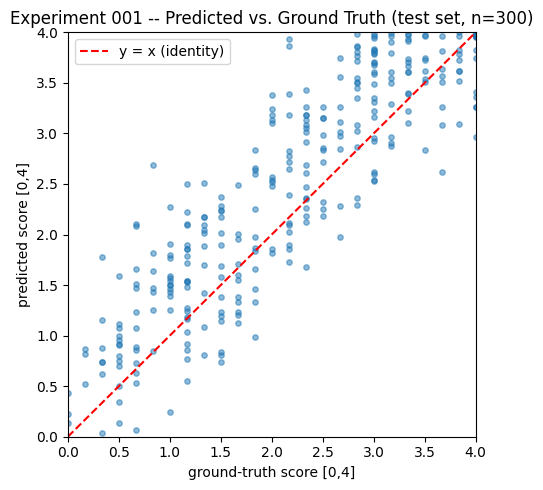

saved results\figures\001_resnet50_baseline_test_pred_vs_gt.png


In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gt_raw_arr, pred_raw_arr, alpha=0.5, s=15)
ax.plot([SCORE_MIN, SCORE_MAX], [SCORE_MIN, SCORE_MAX], "r--", label="y = x (identity)")
ax.set_xlabel("ground-truth score [0,4]")
ax.set_ylabel("predicted score [0,4]")
ax.set_xlim(SCORE_MIN, SCORE_MAX)
ax.set_ylim(SCORE_MIN, SCORE_MAX)
ax.legend()
ax.set_title(f"Experiment 001 -- Predicted vs. Ground Truth (test set, n={len(records)})")
plt.tight_layout()
fig_path = Path("results/figures/001_resnet50_baseline_test_pred_vs_gt.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

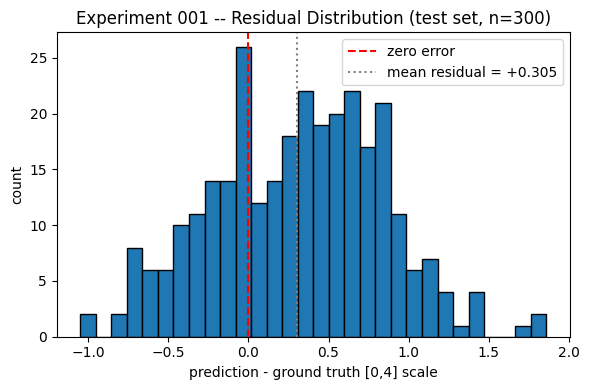

saved results\figures\001_resnet50_baseline_test_residuals.png


In [12]:
residuals = pred_raw_arr - gt_raw_arr

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=30, edgecolor="black")
ax.axvline(0.0, color="red", linestyle="--", label="zero error")
ax.axvline(residuals.mean(), color="gray", linestyle=":", label=f"mean residual = {residuals.mean():+.3f}")
ax.set_xlabel("prediction - ground truth [0,4] scale")
ax.set_ylabel("count")
ax.set_title(f"Experiment 001 -- Residual Distribution (test set, n={len(records)})")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/001_resnet50_baseline_test_residuals.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

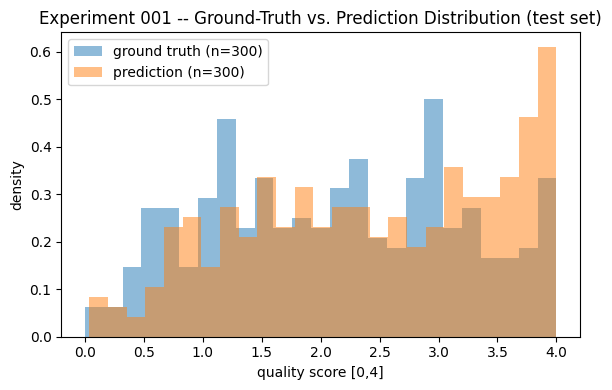

saved results\figures\001_resnet50_baseline_test_score_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gt_raw_arr, bins=25, alpha=0.5, density=True, label=f"ground truth (n={len(gt_raw_arr)})")
ax.hist(pred_raw_arr, bins=25, alpha=0.5, density=True, label=f"prediction (n={len(pred_raw_arr)})")
ax.set_xlabel("quality score [0,4]")
ax.set_ylabel("density")
ax.set_title("Experiment 001 -- Ground-Truth vs. Prediction Distribution (test set)")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/001_resnet50_baseline_test_score_distribution.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

## Paper Comparison (contextual only -- not a numerical comparison)

| | Ohashi (paper) | This experiment |
|---|---|---|
| Label source | Synthetic degradation + VIF | LDCT-IQAC real radiologist quality score |
| Dataset | Paper's own (not obtained by this project) | LDCT-IQAC |
| Backbone | RadImageNet ResNet50 | Same |

The PLCC/SROCC/KROCC numbers above are **not** compared directly against
the paper's reported correlation values -- the label semantics and
datasets differ (see `docs/replication/dataset_adaptation.md`), so a
"we achieved X vs. their Y" statement would misrepresent what was actually
measured. This experiment's result stands on its own as a baseline for
*this* dataset adaptation.

## Test Set Contamination Check

In [14]:
print("=== TEST SET CONTAMINATION CHECK ===")
print("- Checkpoint was selected during training using VALIDATION loss only")
print("  (see experiments/001_resnet50_baseline/README.md) -- this notebook did not")
print("  participate in that selection and ran strictly after it was already fixed.")
print("- No hyperparameter in configs/*.yaml was chosen using any number produced by this notebook.")
print("- No calibration was fit on the test set (see 'Calibration -- Deferred' above).")
print("- This notebook never constructs a training or validation DataLoader/Dataset.")
print()
print("TEST SET USED ONLY FOR FINAL EVALUATION.")

=== TEST SET CONTAMINATION CHECK ===
- Checkpoint was selected during training using VALIDATION loss only
  (see experiments/001_resnet50_baseline/README.md) -- this notebook did not
  participate in that selection and ran strictly after it was already fixed.
- No hyperparameter in configs/*.yaml was chosen using any number produced by this notebook.
- No calibration was fit on the test set (see 'Calibration -- Deferred' above).
- This notebook never constructs a training or validation DataLoader/Dataset.

TEST SET USED ONLY FOR FINAL EVALUATION.


## Notes

- Re-running this notebook re-executes inference and OVERWRITES the
  `results/` artifacts above with the same values (deterministic given the
  same checkpoint and `model.eval()`/`torch.no_grad()`) -- it never
  retrains or modifies `experiments/001_resnet50_baseline/checkpoint/`.
- If `experiments/001_resnet50_baseline/checkpoint/best.pt` does not exist,
  the checkpoint-loading cell above raises an `AssertionError` rather than
  silently evaluating an untrained model -- this notebook always reports a
  fully-trained checkpoint's result, or fails loudly.